In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/india_agriculture_seed_sales_data.csv')


In [2]:
df.head(5)

,Date,Year,Month,Region,Vegetable_Type,Warehouse_Quantity,Competitor_Market_Share_%,Company_Market_Share_%,Farmer_Sentiment_Score,Soil_pH,...,Wholesale_Price,Retail_Price,Farmer_Share_%,Sales_Target,Actual_Units_Sold,Total_Revenue,Total_Cost,Profit_Margin_%,Revenue_Growth_%,Days_to_Sell_Inventory
0,2021-01,2021,1,West,Carrot,5983,68.0,32.0,9.48,7.03,...,307.88,554.18,28.4,951,1123,230495.44,207676.39,9.90,3.55,61.3
1,2021-01,2021,1,Central,Chili,6704,42.3,57.7,4.86,6.12,...,253.20,455.76,20.7,868,1061,179093.74,159160.61,11.13,6.84,68.2
2,2021-01,2021,1,East,Chili,6383,59.7,40.3,8.62,6.19,...,239.67,431.41,26.1,1045,575,91872.03,79258.00,13.73,2.56,44.2
3,2021-01,2021,1,Central,Chili,4844,50.7,49.3,7.23,7.44,...,314.94,566.89,24.8,802,625,131222.69,114137.50,13.02,1.28,79.7
4,2021-01,2021,1,Central,Tomato,6924,49.3,50.7,7.73,7.40,...,336.13,605.03,21.1,1478,1030,230816.33,204341.70,11.47,4.80,75.5


In [4]:
## Unique values

print("Regions:", df['Region'].unique())           # 5 regions
print("Vegetables:", df['Vegetable_Type'].unique()) # 20 crops
print("Year Range:", df['Year'].min(), '–', df['Year'].max())

Regions: <StringArray>
['West', 'Central', 'East', 'South', 'North']
Length: 5, dtype: str
Vegetables: <StringArray>
['Carrot', 'Chili', 'Tomato', 'Onion', 'Cauliflower', 'Okra']
Length: 6, dtype: str
Year Range: 2021 – 2026


 Revenue Trend by Year

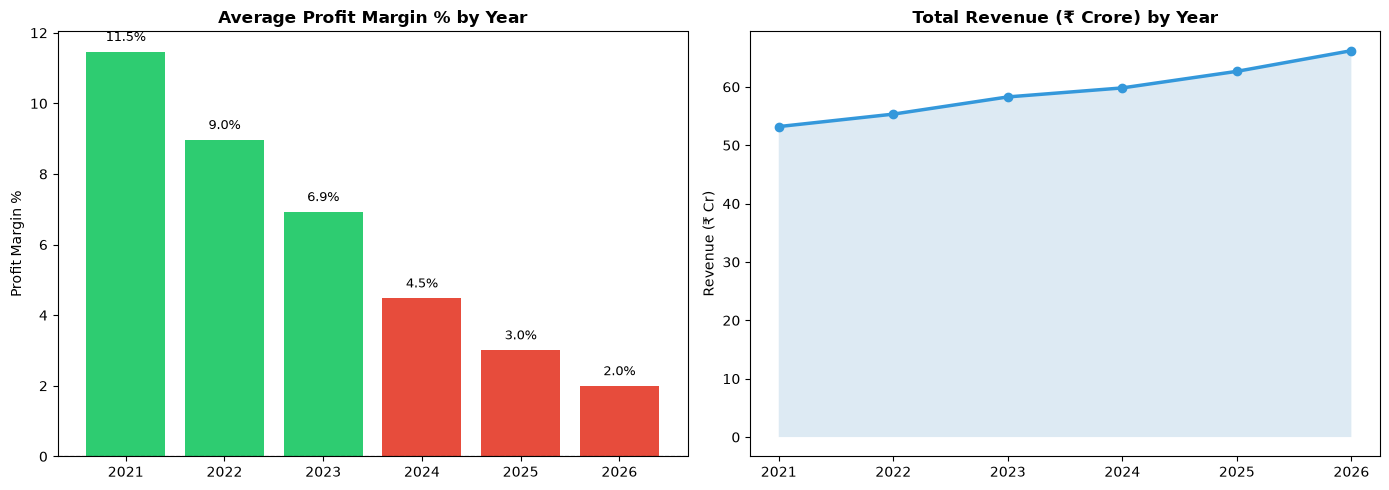

 Year  Avg_Profit_Margin  Total_Revenue   Total_Cost  Revenue_Cr
 2021          11.468362   531976379.63 470631038.74   53.197638
 2022           8.973111   553320221.44 503590982.66   55.332022
 2023           6.932271   582800077.92 542115541.39   58.280008
 2024           4.485485   598234575.39 571318971.73   59.823458
 2025           3.015110   626614543.02 607619627.82   62.661454
 2026           1.999988   662075603.96 648812707.73   66.207560


In [5]:
# Profit Margin Trend (Annual) 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

annual = df.groupby('Year').agg(
    Avg_Profit_Margin=('Profit_Margin_%','mean'),
    Total_Revenue=('Total_Revenue','sum'),
    Total_Cost=('Total_Cost','sum')
).reset_index()
annual['Revenue_Cr'] = annual['Total_Revenue'] / 1e7

axes[0].bar(annual['Year'], annual['Avg_Profit_Margin'],
            color=[('#e74c3c' if v < 5 else '#2ecc71') for v in annual['Avg_Profit_Margin']])
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Average Profit Margin % by Year', fontweight='bold')
axes[0].set_ylabel('Profit Margin %')
for i, row in annual.iterrows():
    axes[0].text(row['Year'], row['Avg_Profit_Margin']+0.3, f"{row['Avg_Profit_Margin']:.1f}%",
                 ha='center', fontsize=9)

axes[1].plot(annual['Year'], annual['Revenue_Cr'], marker='o', color='#3498db', linewidth=2.5)
axes[1].fill_between(annual['Year'], annual['Revenue_Cr'], alpha=0.15)
axes[1].set_title('Total Revenue (₹ Crore) by Year', fontweight='bold')
axes[1].set_ylabel('Revenue (₹ Cr)')

plt.tight_layout()
plt.savefig('../outputs/figures/revenue_trend.png', bbox_inches='tight')
plt.show()
print(annual.to_string(index=False))

Profit Margin by Region

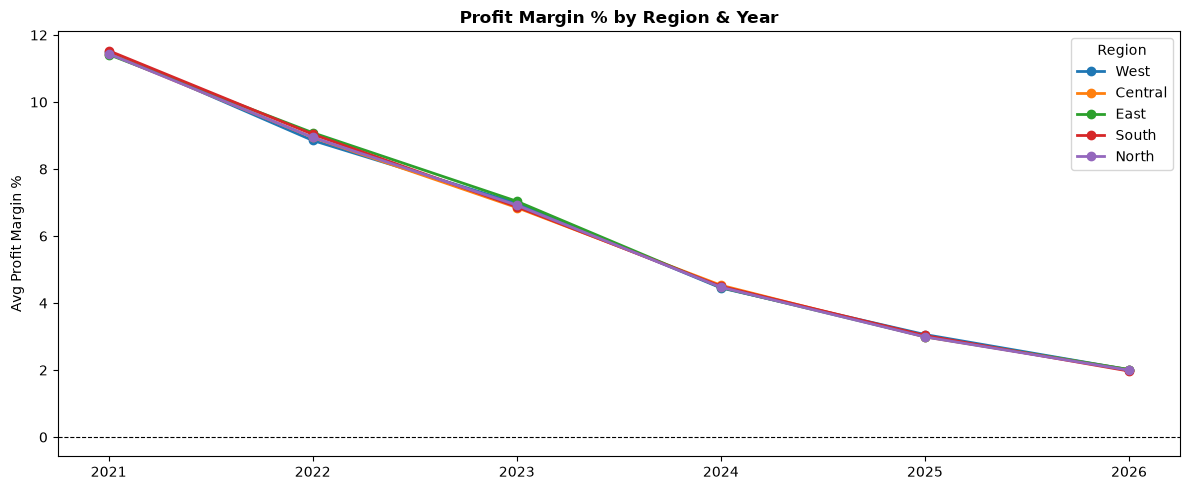

In [7]:
# Profit by Region
region_profit = df.groupby(['Year','Region'])['Profit_Margin_%'].mean().reset_index()
PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
           '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
fig, ax = plt.subplots(figsize=(12, 5))
for i, region in enumerate(df['Region'].unique()):
    sub = region_profit[region_profit['Region'] == region]
    ax.plot(sub['Year'], sub['Profit_Margin_%'], marker='o',
            label=region, linewidth=2, color=PALETTE[i])
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Profit Margin % by Region & Year', fontweight='bold')
ax.set_ylabel('Avg Profit Margin %')
ax.legend(title='Region')
plt.tight_layout()
plt.savefig('../outputs/figures/region_profit.png', bbox_inches='tight')
plt.show()

Profit by Vegetable Type 

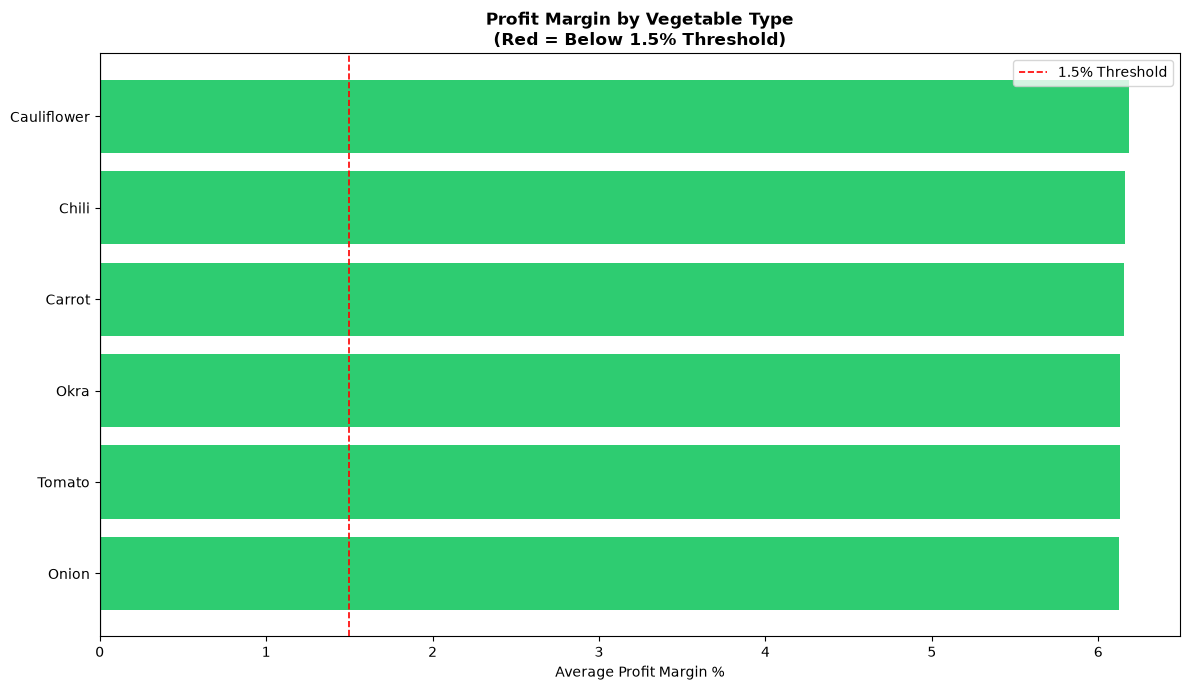


--- Vegetables BELOW 1.5% Margin Threshold ---
Empty DataFrame
Columns: [Vegetable_Type, Avg_Margin]
Index: []


In [8]:
# Vegetable-Level Profitability 
veg_profit = df.groupby('Vegetable_Type').agg(
    Avg_Margin=('Profit_Margin_%','mean'),
    Total_Rev=('Total_Revenue','sum'),
    Avg_Units=('Actual_Units_Sold','mean')
).sort_values('Avg_Margin').reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if m < 1.5 else '#f39c12' if m < 5 else '#2ecc71'
          for m in veg_profit['Avg_Margin']]
bars = ax.barh(veg_profit['Vegetable_Type'], veg_profit['Avg_Margin'], color=colors)
ax.axvline(1.5, color='red', linestyle='--', linewidth=1.2, label='1.5% Threshold')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Average Profit Margin %')
ax.set_title('Profit Margin by Vegetable Type\n(Red = Below 1.5% Threshold)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/vegetable_profit.png', bbox_inches='tight')
plt.show()

print('\n--- Vegetables BELOW 1.5% Margin Threshold ---')
print(veg_profit[veg_profit['Avg_Margin'] < 1.5][['Vegetable_Type','Avg_Margin']].to_string(index=False))

Correlation Heatmap

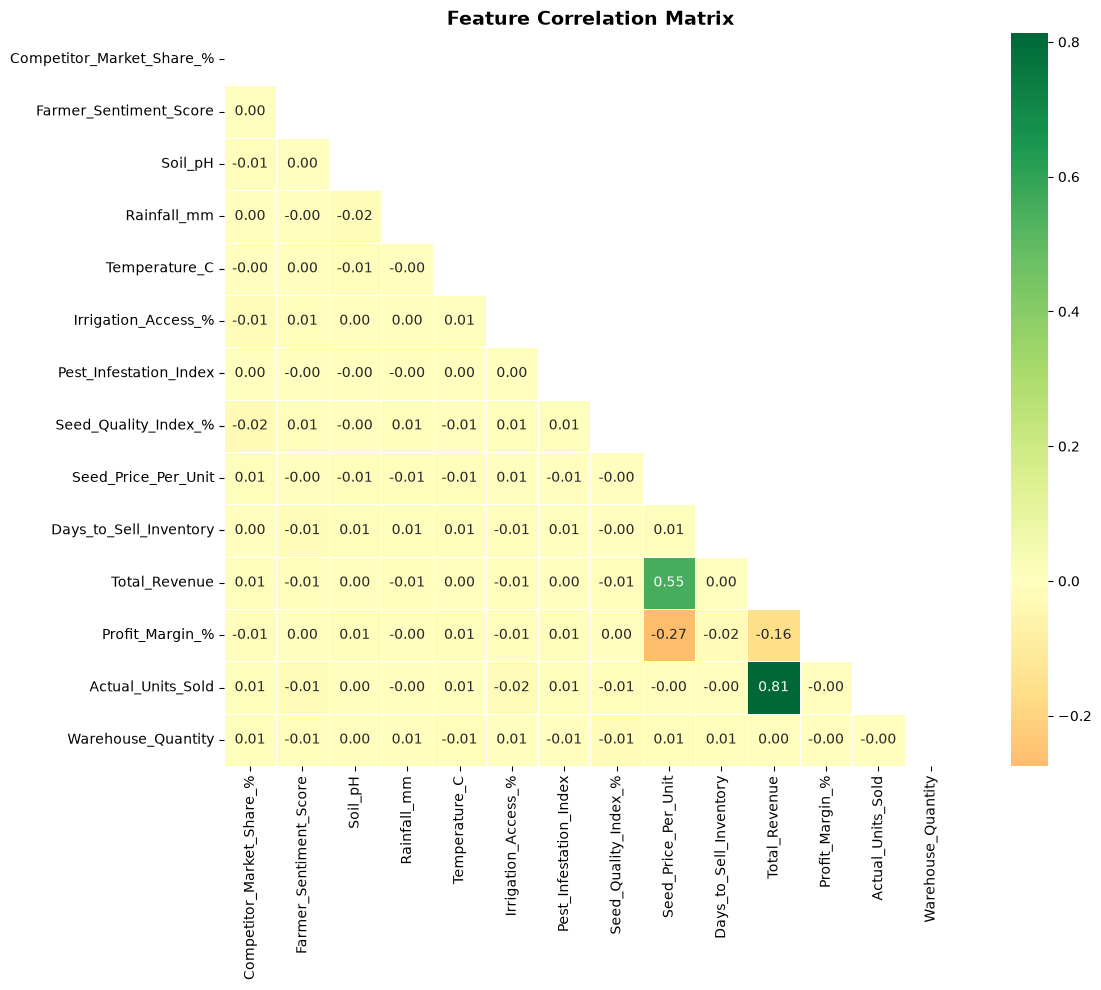

In [10]:
# Correlation Heatmap
num_cols = ['Competitor_Market_Share_%','Farmer_Sentiment_Score','Soil_pH',
            'Rainfall_mm','Temperature_C','Irrigation_Access_%',
            'Pest_Infestation_Index','Seed_Quality_Index_%','Seed_Price_Per_Unit',
            'Days_to_Sell_Inventory','Total_Revenue','Profit_Margin_%',
            'Actual_Units_Sold','Warehouse_Quantity']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0, annot=True,
            fmt='.2f', linewidths=0.4, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()

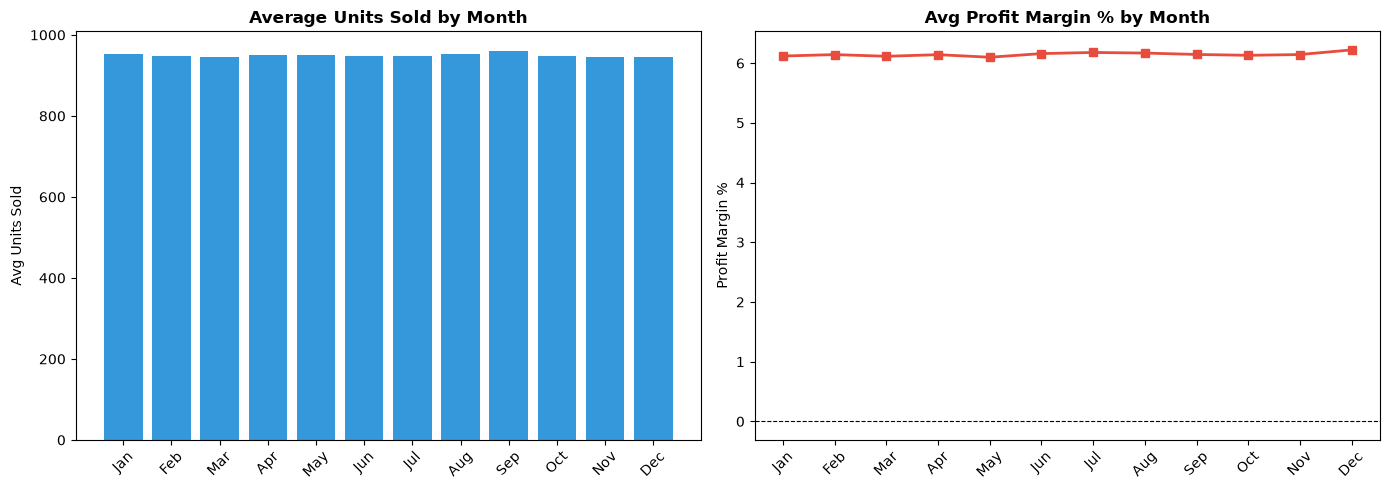

In [10]:
# Monthly Seasonality
monthly = df.groupby('Month').agg(
    Avg_Units=('Actual_Units_Sold','mean'),
    Avg_Revenue=('Total_Revenue','mean'),
    Avg_Margin=('Profit_Margin_%','mean')
).reset_index()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['Month_Name'] = monthly['Month'].apply(lambda x: months[x-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(monthly['Month_Name'], monthly['Avg_Units'], color='#3498db')
axes[0].set_title('Average Units Sold by Month', fontweight='bold')
axes[0].set_ylabel('Avg Units Sold')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['Month_Name'], monthly['Avg_Margin'], marker='s',
             color='#e74c3c', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Avg Profit Margin % by Month', fontweight='bold')
axes[1].set_ylabel('Profit Margin %')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/monthly_seasonality.png', bbox_inches='tight')
plt.show()

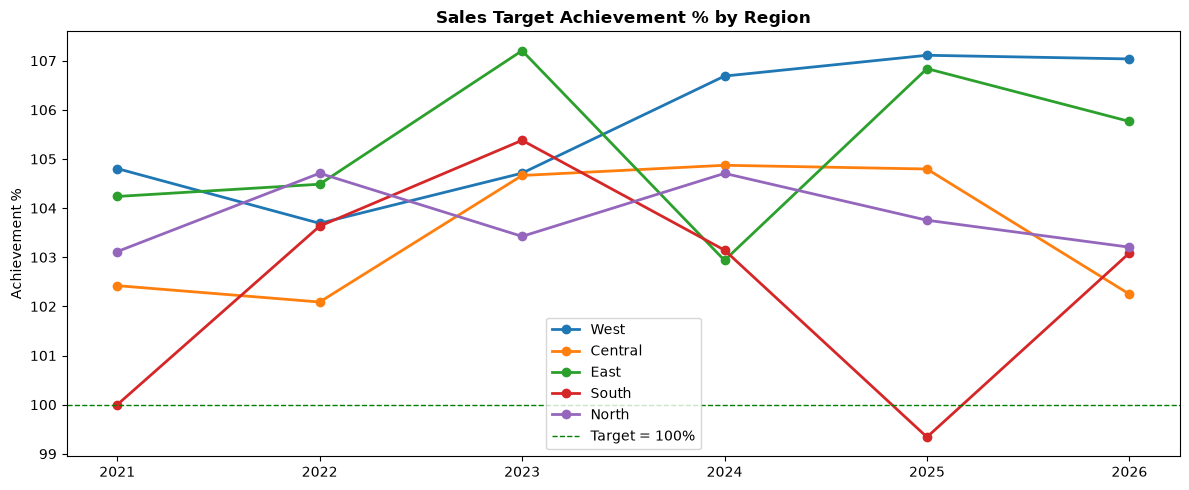

In [13]:
# Sales Target Achievement Rate 
df['Target_Achievement_%'] = (df['Actual_Units_Sold'] / df['Sales_Target'] * 100)
ta_region = df.groupby(['Year','Region'])['Target_Achievement_%'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for i, region in enumerate(df['Region'].unique()):
    sub = ta_region[ta_region['Region'] == region]
    ax.plot(sub['Year'], sub['Target_Achievement_%'], marker='o',
            label=region, linewidth=2, color=PALETTE[i])
ax.axhline(100, color='green', linestyle='--', linewidth=1, label='Target = 100%')
ax.set_title('Sales Target Achievement % by Region', fontweight='bold')
ax.set_ylabel('Achievement %')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/target_achievement.png', bbox_inches='tight')
plt.show()


In [12]:
print('\n=== EDA COMPLETE — Key Findings ===')
print(f"• Avg profit margin 2025: {df[df['Year']==2025]['Profit_Margin_%'].mean():.2f}%")
print(f"• Avg competitor market share: {df['Competitor_Market_Share_%'].mean():.1f}%")
print(f"• Avg days to sell inventory: {df['Days_to_Sell_Inventory'].mean():.1f} days")
print(f"• Overall target achievement: {df['Target_Achievement_%'].mean():.1f}%")


=== EDA COMPLETE — Key Findings ===
• Avg profit margin 2025: 3.02%
• Avg competitor market share: 57.5%
• Avg days to sell inventory: 65.0 days
• Overall target achievement: 104.1%
